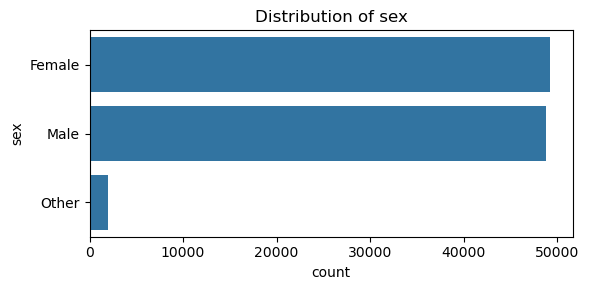

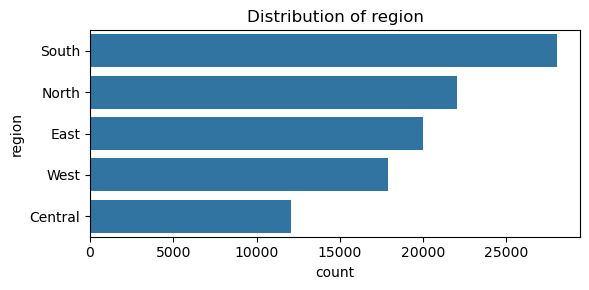

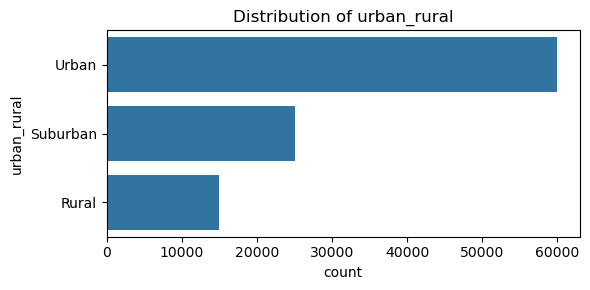

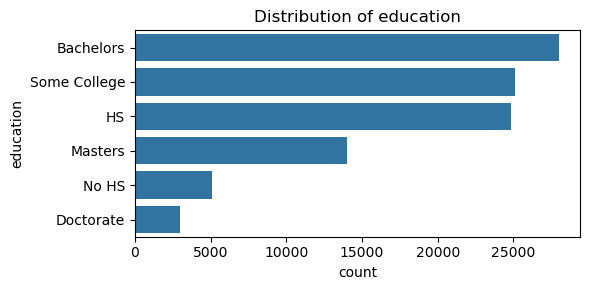

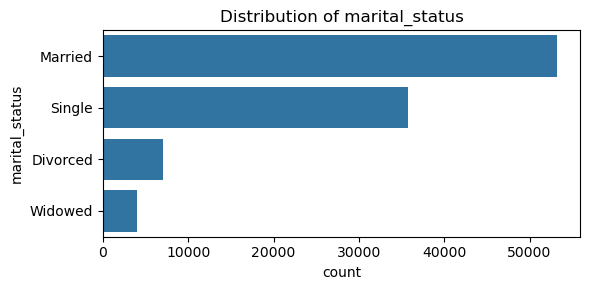

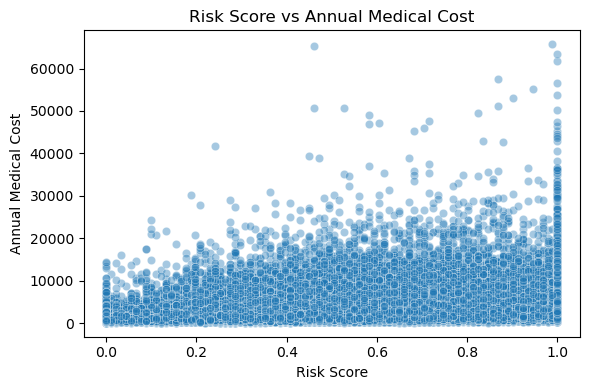

In [4]:
# ==============================================================
# Simplified EDA Visualization for Medical Insurance Dataset
# ==============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv("medical_insurance.csv")

# 2. Select categorical and key numeric features
cat_cols = df.select_dtypes(include=['object']).columns

# 3. Plot bar charts for first few categorical variables
for c in cat_cols[:5]:  # Show first 5 categorical columns
    plt.figure(figsize=(6,3))
    sns.countplot(y=c, data=df, order=df[c].value_counts().index)
    plt.title(f"Distribution of {c}", fontsize=12)
    plt.tight_layout()
    plt.show()

# 4. Scatter plot: Risk score vs annual medical cost
plt.figure(figsize=(6,4))
sns.scatterplot(x="risk_score", y="annual_medical_cost", data=df, alpha=0.4)
plt.title("Risk Score vs Annual Medical Cost", fontsize=12)
plt.xlabel("Risk Score")
plt.ylabel("Annual Medical Cost")
plt.tight_layout()
plt.show()

In [9]:
# ==============================================================
# Regression Models: Predict Annual Medical Cost (Full Version)
# ==============================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# 1. Load dataset
df = pd.read_csv("medical_insurance.csv")

# 2. Define features and target
y = df["annual_medical_cost"]
X = df.drop(columns=["annual_medical_cost", "is_high_risk", "person_id"])

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Preprocessing
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

# =========================
# 5. Linear Regression
# =========================
lin_model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", LinearRegression())
])
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)

print("=== Linear Regression ===")
print("R²:", r2_score(y_test, y_pred_lin))
print("RMSE:", rmse_lin)

# =========================
# 6. Random Forest Regressor
# =========================
rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200, max_depth=12, random_state=42, n_jobs=-1))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("\n=== Random Forest Regressor ===")
print("R²:", r2_score(y_test, y_pred_rf))
print("RMSE:", rmse_rf)

# =========================
# 7. XGBoost Regressor
# =========================
xgb_model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8, random_state=42))
])
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print("\n=== XGBoost Regressor ===")
print("R²:", r2_score(y_test, y_pred_xgb))
print("RMSE:", rmse_xgb)

=== Linear Regression ===
R²: 0.9664198360607464
RMSE: 574.8337120166939

=== Random Forest Regressor ===
R²: 0.9982189882879229
RMSE: 132.3836075563333

=== XGBoost Regressor ===
R²: 0.9759295972410317
RMSE: 486.67888304799106


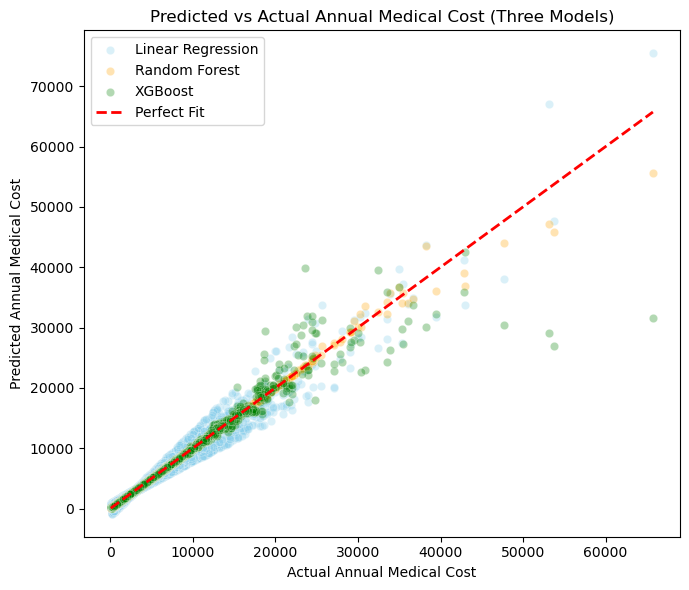

In [10]:
# ==============================================================
# Regression Performance Comparison: Predicted vs Actual
# ==============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot comparing three regression models
plt.figure(figsize=(7, 6))

sns.scatterplot(x=y_test, y=y_pred_lin, alpha=0.3, label="Linear Regression", color="skyblue")
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.3, label="Random Forest", color="orange")
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.3, label="XGBoost", color="green")

# Plot reference line y = x
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label="Perfect Fit")

plt.xlabel("Actual Annual Medical Cost")
plt.ylabel("Predicted Annual Medical Cost")
plt.title("Predicted vs Actual Annual Medical Cost (Three Models)")
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
# ==============================================================
# Classification Models with Timing (Logistic, LinearSVC, RF)
# ==============================================================
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# 1. Load dataset
df = pd.read_csv("medical_insurance.csv")

# 2. Define features and target
y = df["is_high_risk"]
X = df.drop(columns=["annual_medical_cost", "is_high_risk", "person_id"])

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Preprocessing: standardize numeric features, encode categorical
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

# 5. Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42),
    "Linear SVM": LinearSVC(max_iter=3000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
}

# 6. Train, time, and evaluate models
results = []
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("clf", model)])
    start = time.time()
    pipe.fit(X_train, y_train)
    end = time.time()
    
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    duration = end - start
    
    results.append((name, acc, duration))
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Training + Prediction Time: {duration:.2f} sec")

# 7. Summary table
print("\n=== Summary ===")
for name, acc, t in results:
    print(f"{name:<20} | Accuracy: {acc:.4f} | Time: {t:.2f} sec")


=== Logistic Regression ===
Accuracy: 0.9997
Training + Prediction Time: 1.47 sec

=== Linear SVM ===
Accuracy: 1.0000
Training + Prediction Time: 0.49 sec

=== Random Forest ===
Accuracy: 1.0000
Training + Prediction Time: 2.12 sec

=== Summary ===
Logistic Regression  | Accuracy: 0.9997 | Time: 1.47 sec
Linear SVM           | Accuracy: 1.0000 | Time: 0.49 sec
Random Forest        | Accuracy: 1.0000 | Time: 2.12 sec


In [2]:
# ==============================================================
# Task: Predict Top-10% High-Cost Members (Harder Binary Task)
# - Label = 1 if annual_medical_cost >= 90th percentile
# - Drop potential leakage features (claims/cost-derived)
# - Metrics: ROC-AUC, PR-AUC, best-threshold F1; timing
# ==============================================================

import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# 1) Load data
df = pd.read_csv("medical_insurance.csv")

# 2) Build hard label: top-10% by annual_medical_cost
q90 = df["annual_medical_cost"].quantile(0.90)
y = (df["annual_medical_cost"] >= q90).astype(int)

# 3) Remove outcome/leakage-like features:
#    Anything that is directly cost/claims related is excluded from predictors.
leak_like = [
    "annual_medical_cost", "total_claims_paid", "claims_count",
    "proc_imaging_count", "proc_surgery_count", "proc_physio_count",
    "proc_consult_count", "proc_lab_count"
]
# Optionally remove engineered risk summaries that might be too close to outcome
maybe_leaky_scores = ["risk_score", "had_major_procedure", "is_high_risk"]
drop_cols = [c for c in leak_like + maybe_leaky_scores if c in df.columns]

X = df.drop(columns=drop_cols + ["person_id"])  # keep demographic/behavior/labs, etc.

# 4) Train/test split (stratify to preserve positive rate)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5) Preprocess: scale numeric + one-hot categorical
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

# 6) Define compact, fast models
models = {
    "Logistic": LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42),
    "LinearSVM": LinearSVC(max_iter=3000, random_state=42),  # no predict_proba
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=12, n_jobs=-1, random_state=42
    )
}

def eval_binary(pipe, name):
    """Fit, time, and compute ROC-AUC, PR-AUC, and best-threshold F1."""
    start = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - start

    # Scores/probabilities for metrics
    # For LinearSVC, use decision_function; for others, use predict_proba
    if hasattr(pipe.named_steps["clf"], "predict_proba"):
        scores = pipe.predict_proba(X_test)[:, 1]
    else:
        scores = pipe.decision_function(X_test)

    # Threshold sweep for best F1
    precision, recall, thr = precision_recall_curve(y_test, scores)
    f1s = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.nanargmax(f1s))
    best_thr = thr[best_idx]
    y_pred_best = (scores >= best_thr).astype(int)

    # Metrics
    roc = roc_auc_score(y_test, scores)
    pr = average_precision_score(y_test, scores)  # PR-AUC
    f1 = f1_score(y_test, y_pred_best)

    return {
        "name": name,
        "roc_auc": roc,
        "pr_auc": pr,
        "best_f1": f1,
        "best_thr": float(best_thr),
        "time_sec": fit_time
    }

# 7) Run and summarize
results = []
for name, clf in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("clf", clf)])
    res = eval_binary(pipe, name)
    results.append(res)
    print(f"\n=== {name} ===")
    print(f"ROC-AUC: {res['roc_auc']:.4f} | PR-AUC: {res['pr_auc']:.4f} | "
          f"Best-F1: {res['best_f1']:.4f} @ thr={res['best_thr']:.3f} | "
          f"Time: {res['time_sec']:.2f}s")

# Optional: pretty dataframe
summary = pd.DataFrame(results).sort_values(by="pr_auc", ascending=False)
print("\nSummary (sorted by PR-AUC):")
print(summary)


=== Logistic ===
ROC-AUC: 1.0000 | PR-AUC: 0.9999 | Best-F1: 0.9948 @ thr=0.457 | Time: 1.34s

=== LinearSVM ===
ROC-AUC: 1.0000 | PR-AUC: 1.0000 | Best-F1: 0.9968 @ thr=-0.044 | Time: 0.35s

=== RandomForest ===
ROC-AUC: 0.9998 | PR-AUC: 0.9982 | Best-F1: 0.9861 @ thr=0.476 | Time: 2.55s

Summary (sorted by PR-AUC):
           name   roc_auc    pr_auc   best_f1  best_thr  time_sec
1     LinearSVM  0.999996  0.999963  0.996757 -0.043892  0.348518
0      Logistic  0.999990  0.999907  0.994767  0.456703  1.343707
2  RandomForest  0.999787  0.998194  0.986104  0.476244  2.545805


In [3]:
# ==============================================================
# Task: 3-Class Cost Tiering (Low / Mid / High)
# - Tiers by quantiles: <=33%, 33~66%, >=66%
# - Metrics: macro-F1 (class-balanced), timing
# ==============================================================

import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("medical_insurance.csv")

# Create 3-class label from annual cost
q33, q66 = df["annual_medical_cost"].quantile([0.33, 0.66])
def to_tier(v):
    if v <= q33: return 0  # Low
    if v >= q66: return 2  # High
    return 1               # Mid

y = df["annual_medical_cost"].apply(to_tier)

# Drop leakage-like columns
leak_like = [
    "annual_medical_cost", "total_claims_paid", "claims_count",
    "proc_imaging_count", "proc_surgery_count", "proc_physio_count",
    "proc_consult_count", "proc_lab_count"
]
maybe_leaky_scores = ["risk_score", "had_major_procedure", "is_high_risk"]
drop_cols = [c for c in leak_like + maybe_leaky_scores if c in df.columns]
X = df.drop(columns=drop_cols + ["person_id"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

models = {
    "Multinomial Logistic": LogisticRegression(
        multi_class="multinomial", max_iter=1000, n_jobs=-1, random_state=42
    ),
    "KNN (k=9)": KNeighborsClassifier(n_neighbors=9, weights="distance"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=14, n_jobs=-1, random_state=42
    )
}

for name, clf in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("clf", clf)])
    start = time.time()
    pipe.fit(X_train, y_train)
    secs = time.time() - start

    y_pred = pipe.predict(X_test)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    print(f"\n=== {name} ===")
    print(f"Macro-F1: {macro_f1:.4f} | Time: {secs:.2f}s")
    print(classification_report(y_test, y_pred, digits=3))

/Users/qianrunchen/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Multinomial Logistic ===
Macro-F1: 0.9964 | Time: 1.71s
              precision    recall  f1-score   support

           0      0.996     0.997     0.997      6600
           1      0.994     0.995     0.995      6600
           2      0.999     0.997     0.998      6800

    accuracy                          0.996     20000
   macro avg      0.996     0.996     0.996     20000
weighted avg      0.996     0.996     0.996     20000


=== KNN (k=9) ===
Macro-F1: 0.6208 | Time: 0.12s
              precision    recall  f1-score   support

           0      0.598     0.700     0.645      6600
           1      0.469     0.485     0.477      6600
           2      0.834     0.667     0.741      6800

    accuracy                          0.618     20000
   macro avg      0.633     0.617     0.621     20000
weighted avg      0.635     0.618     0.622     20000


=== Random Forest ===
Macro-F1: 0.9765 | Time: 4.42s
              precision    recall  f1-score   support

           0      

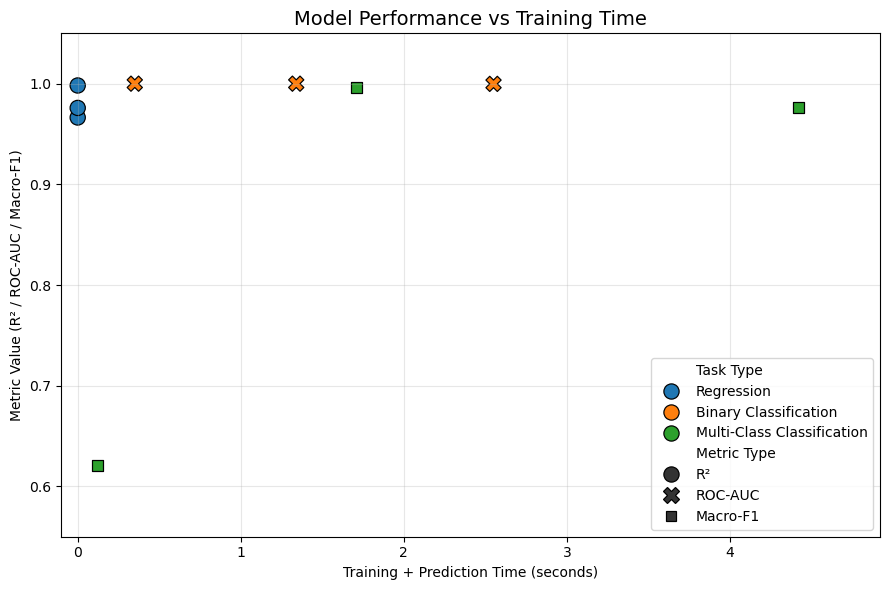

In [5]:
# ==============================================================
# Markers only: no per-point text labels
# ==============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data (same as前面)
data = {
    "Task Type": [
        "Regression", "Regression", "Regression",
        "Binary Classification", "Binary Classification", "Binary Classification",
        "Multi-Class Classification", "Multi-Class Classification", "Multi-Class Classification"
    ],
    "Model": [
        "Linear Regression", "Random Forest Regressor", "XGBoost Regressor",
        "Logistic Regression", "Linear SVM", "Random Forest Classifier",
        "Multinomial Logistic", "KNN (k=9)", "Random Forest (Multi-Class)"
    ],
    "Metric Type": [
        "R²", "R²", "R²",
        "ROC-AUC", "ROC-AUC", "ROC-AUC",
        "Macro-F1", "Macro-F1", "Macro-F1"
    ],
    "Metric Value": [
        0.9664, 0.9982, 0.9759,
        1.0000, 1.0000, 0.9998,
        0.9964, 0.6208, 0.9765
    ],
    "Time (s)": [0.0, 0.0, 0.0, 1.34, 0.35, 2.55, 1.71, 0.12, 4.42]
}
df = pd.DataFrame(data)

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x="Time (s)", y="Metric Value",
    hue="Task Type",          # color by task
    style="Metric Type",      # marker shape by metric
    s=120, edgecolor="black"
)

# No per-point text labels — markers only
# (Do NOT call plt.text for any point)

plt.title("Model Performance vs Training Time", fontsize=14)
plt.xlabel("Training + Prediction Time (seconds)")
plt.ylabel("Metric Value (R² / ROC-AUC / Macro-F1)")
plt.xlim(-0.1, df["Time (s)"].max() + 0.5)
plt.ylim(0.55, 1.05)
plt.grid(True, alpha=0.3)

# If you also want to hide the legend entirely, uncomment the next line:
# plt.legend().remove()

plt.tight_layout()
plt.show()

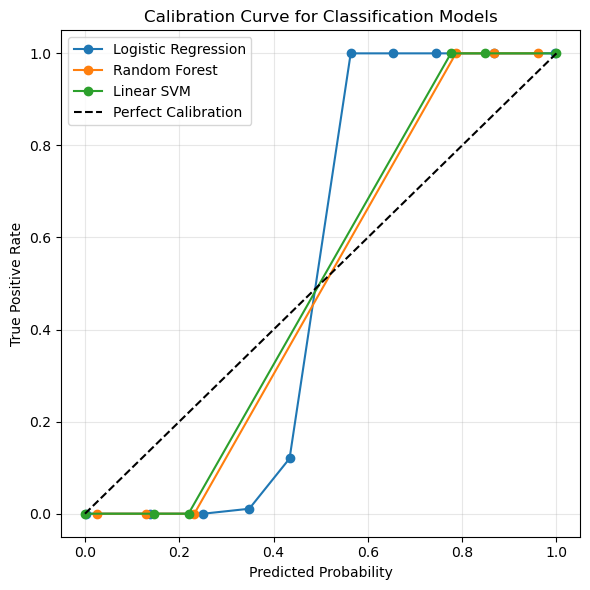

In [6]:
# ==============================================================
# Calibration Curve for Classification Models
# ==============================================================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# 1. Load dataset
df = pd.read_csv("medical_insurance.csv")

# 2. Define features and target
y = df["is_high_risk"]
X = df.drop(columns=["annual_medical_cost", "is_high_risk", "person_id"])

# 3. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Preprocess: scale numeric + encode categorical
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

# 5. Define models (SVM wrapped with calibration for probability)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "Linear SVM": CalibratedClassifierCV(LinearSVC(max_iter=3000, random_state=42))
}

# 6. Fit and plot calibration curves
plt.figure(figsize=(6, 6))

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("clf", model)])
    pipe.fit(X_train, y_train)

    # Predict calibrated probabilities
    y_prob = pipe.predict_proba(X_test)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

    plt.plot(prob_pred, prob_true, marker="o", label=name)

# Reference line: perfect calibration
plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration")

plt.title("Calibration Curve for Classification Models")
plt.xlabel("Predicted Probability")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()